To capture the timescale of adaptation/repetition surpression, we also run a small part of the model within a grid op possible decay strenghts. This grid we previously generated within `stim_modelling`.
Since this hyperparameter space can quickly ascalate into a very broad and storage expensive scale, we limit this grid to 25 positions where `afast` and `tfast` are interlinked and where `aslow` and `tslow` are interlinked.

### prepair modules and bases settings

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix,  classification_report, log_loss
from sklearn.preprocessing import StandardScaler
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier
from scipy.stats import norm
import scipy.io
import re
import itertools

import os
from os.path import join
import contextlib
from copy import deepcopy
import imp 
import time 
import sys

import pickle
from pdb import set_trace

from IPython.display import clear_output, display

In [2]:
# Add the directory containing your modules to the Python path
sys.path.append(os.path.abspath(os.path.join('..', 'ses2_modelstims')))

# load local functions
import stim_io
import stim_io_plotting
import vtc
import bvbabel

/home/jorvhar/miniconda3/envs/predlis/lib/python3.8/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '


In [3]:
import regression
import varpar

In [4]:
## LOADING GRID

# Load from MAT file
variables = scipy.io.loadmat('/media/jorvhar/Data8T/MRIData/timing data/grid_parameters_python.mat')

# Extract individual variables
tunsteps = variables['tunsteps']
freqstep = variables['freqstep']
subsample = variables['subsample']
mustep = variables['mustep']
muarray_bins = variables['muarray_bins']
muarray = variables['muarray']
fwhm = variables['fwhm']
octgrid = variables['octgrid']
sigmagrid = variables['sigmagrid']
pref_range = variables['pref_range']
sharp_range_fwhm = variables['sharp_range_fwhm']
sharp_range = variables['sharp_range']

## 1. Set up regresiion model
Options:

In [5]:
tr = 1.8
volumes = 235

### --- REGRESSION SAVING OPTIONS ---

# set modeltype
# modeltype = LinearRegression() #can be LinearRegression (ols), Ridge(alpha=..), Lasso(alpha=..)  etc.
modeltype = LinearRegression() 
key_ai = ['raw_scores', 'coefs', 'intercepts', 'correlation'] # what keys to median and mean across folds

# model return options
save_predict = False          # save y_pred-y
score_of_interest = 'score'   # what score to use  'score', 'raw_scores', 'coefs', 'intercepts', 'correlation'

# outlier options - #tobeimplemented
SD_lim = 3                    # remove y x sd higher then mean
remove_outliers = False       # if false dont remove sd outliers 

# what regressor variant to use
convolved = True   # use convolved dataset
resampled = True   # use scipy resampled data, instead of standard mean for downsampled data

zs=True  # zscore y
ts=False # temporally smooth y
hp=False  # highpass filter y
dr=False  # drift regressors

### --- LOCATION OPTIONS ---

# file location
mridat_dir = '/media/jorvhar/Data8T/MRIData/PreProc'
logdat_dir = '/media/jorvhar/Data8T/MRIData/timing data/data'
vtc_dir = '/media/jorvhar/New Volume1/vtcs' # adviced to put vtc's on a (nvme) ssd while running analyses
pp_dir = lambda pp, ses : f'S{pp:02d}_SES{ses}'
betas_dir = 'Betas'

# tonotopy and mask filenames
tonotopy_vmp = 'prf_permutations_for_s2.vmp'
mask_fn = 'gm-subcortical.msk'

# fn lambda
fn = lambda pp, ses, run : f'S{pp:02d}_SES{ses}_run{run}_FMR_SCSTBL_3DMAS_THPGLMF7c_TOPUP_ANTS.vtc'


### --- PARTICIPANT OPTIONS ---

# session of interest
ses = 2

# variable that may be different per participant
ppz = [1,2,3,4,5,6,7,8,9,10]
n_runz = [12,12,10,10,10,10,10,10,10,10]        # number of runs
startpp = 1

### --- SET THEORIE REGRESSION MODELS ---

models = ['base',
          'adaptation',
          'base_U_adaptation']

## REGRESSORS IN MODELS ##
model_regressors = {'base':       ['raw_acti', 'onoff'], 
                    'adaptation': ['raw_adapt' ],      # adaptation
                    'prediction': ['pred_prob',   # voxelwise prior liklihood
                                   'surprisal',   # global prior surprise
                                   'precision']   # global precision
                   } 

# if we want to add adapted activation
# model_regressors['adaptation'] += ['adapt_activ']

# set combination of regressors
model_regressors.update({'base_U_adaptation':             model_regressors['base']+
                                                          model_regressors['adaptation'],
                        'base_U_prediction':              model_regressors['base']+
                                                          model_regressors['prediction'], 
                        'adaptation_U_prediction':        model_regressors['adaptation']+
                                                          model_regressors['prediction'], 
                        'base_U_adaptation_U_prediction': model_regressors['base']+
                                                          model_regressors['adaptation']+
                                                          model_regressors['prediction']})
y_var = 'voxeltimecourse'

## 2. Run regressions - per participant - per model - per gridpostion 
Run the full regressions, looping over participants, copy pasting files to a suitable ssd location, and doing the regression for the full grid.

In [7]:
# load adaptation grid
with open(join(logdat_dir, 'adapt_grid.pickle'), 'rb') as handle:
    decay_data = pickle.load(handle)
    
# cononical hrf
hrf = scipy.io.loadmat('/media/jorvhar/Data8T/MRIData/timing data/hrf.mat')

# loop over all participants
for pp_idx in np.arange(ppz.index(startpp),len(ppz)):

    ### --- PREPARE PARTICIPANT DATA ---

    # fetch current pp vars
    pp = ppz[pp_idx]
    runz = np.arange(1,n_runz[pp_idx]+1)
    runs = n_runz[pp_idx]

    print(F'--RUNNING REGRESSION LOOP FOR PP: {pp} (runs={n_runz[pp_idx]})--')

    # load stim df and tr df
    #### INSTEAD OF LOADING WE MUST GENERATE ON THE FLY, AS OTHERWISE ITS TOO MEMORY INTENSIVE
    stim_df = stim_io.load_df(logdat_dir, pp, fn='processed_df_stim')
    tr_df = stim_io.load_df(logdat_dir, pp, fn='processed_df_tr')

    # load list of filenames at origin, and vtc filenames
    origin_fns = [join(mridat_dir, pp_dir(pp, ses), fn(pp,ses,run)) for run in runz]
    vtc_fns = [join(vtc_dir, fn(pp,ses,run)) for run in runz]

    # copy files to ssd for efficient and fast chuck processing
    stim_io.copy_files(origin_fns, vtc_fns)
    
    # loop over full grid
    for gridpos in decay_data.keys():
        
        # get current y_decay
        y_decay = decay_data[gridpos]['y_decay']
    
    ###########################################################################################
    ##  DO ON THE FLY STIM_DF GENERATION - AS PRESAVING EVERYTHING WOULD BE TOO MUCH STORAGE ##
    ###########################################################################################
    
        # -------------------------------------------------- #
        ## 1. Loading in the log-data from experimental file #
        puls_df = stim_io.pulses_load(str(pp), logdat_dir, runs)
        puls_df = stim_io.pulses_check(puls_df, fix=True)  # check (/fix) inconsistent puls df lengths
        volumes_df = stim_io.volumes_load(puls_df, tr, volumes, nr_runs=runs)
        mat, stimuli = stim_io.data_load(str(pp), join(logdat_dir, str(pp)))
        stim_df = stim_io.stims_load(puls_df, volumes_df, mat, stimuli)

        # -------------------------------------------------- #
        ## 2a. Add D-Rex to dataframe (pre-saved)            #
        stim_df = stim_io.stims_add_drex(str(pp), logdat_dir, stim_df)
        ## 2b. Add trial level adaptation                    #
        activations, adaptations, adapted_activations, n_back_adaptations = stim_io.run_adaptation(stim_df, 
                                                                                                   pref_range[0], 
                                                                                                   sharp_range[0], 
                                                                                                   y_decay)
        stim_df = stim_io.stims_add_adaptation(stim_df, 
                                               pref_range[0], 
                                               sharp_range[0], 
                                               activations, 
                                               1-adaptations,       # take 1-adaptation to make filling with 0s possible
                                               adapted_activations)
        del activations, adaptations, adapted_activations, n_back_adaptations # cleanup vars for memory

        # ------------------------------------------------------- #
        ## 3. Trasnsfer stim_df from stimulus domain to TR domain #

        # main function for adding timesteps (inbetween runs, / blocks)
        stim_df = stim_io.stims_add_temporal_pad(stim_df, volumes_df)
        # convolve stim_df with hrf (the regressors)
        newhrf = stim_io.con_hrf_stimdomain(hrf, stim_df, plotres=False)
        stim_df = stim_io.stims_convolve_hrf(stim_df, newhrf)
        # to get dataframe in tr space
        tr_df = stim_io.stims_to_tr(stim_df, volumes_df, downsample_unconv=True) # was False
    
    
    ###########################################################################################
    ##                        START ACTUAL REGRESSION PROCESS                                ##
    ###########################################################################################
    
        # create full path for vmp and mask
        mskpath = join(mridat_dir, pp_dir(pp,1), mask_fn)
        vmppath = join(mridat_dir, pp_dir(pp,1), betas_dir, tonotopy_vmp)

        # load full mask and convert to indeces
        _, msk = bvbabel.msk.read_msk(mskpath)
        msk = np.where(msk)

        # load vmp image
        vmp_head, vmp_img = bvbabel.vmp.read_vmp(vmppath)

        # load tonotopy vmp
        vmp_df = stim_io.vmp_add_realsigma(vmp_img, msk, mustep[0][0]) # 1. prfMU, 2. prfMU_hz, prfS, prfO


    ### --- RUN FULL REGRESSION ---

        # run full regression for current pp
        scores = regression.run_model_grid_noncv(tr_df,stim_df,vmp_df,vtc_fns,
                                           msk, vmp_img,
                                           pref_range,sharp_range,
                                           models, model_regressors,
                                           mustep, modeltype, key_ai,
                                           save_predict=save_predict, 
                                           convolved=convolved, resampled=resampled,
                                           zs=zs, ts=ts, hp=hp, dr=dr)
        
        # clean up prints - for next pp
        clear_output(wait=True)

        # save scores
        if not os.path.exists(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid')):
            os.mkdir(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid'))

        # append the pickle result naming based on cleaning steps 
        shortkey = re.sub(r':(\d+\.\d+)', lambda x: x.group(1).replace('.', '_'), gridpos).replace(',', '')
        pick_fn = f'scores_ANTS_{shortkey}'
        if ts: pick_fn = f'{pick_fn}_tempsmooth'
        if hp: pick_fn = f'{pick_fn}_highpass'
        # pickle the results
        with open(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid',f'{pick_fn}.pickle'), 'wb') as handle:
            pickle.dump(scores, handle, protocol=pickle.HIGHEST_PROTOCOL)
    # loading of pickled results
    ###with open(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid',f'{pick_fn}.pickle'), 'rb') as handle:
    ###    scores = pickle.load(handle)

    # clean up files where needed for next pp
    for fp in vtc_fns:
        os.remove(fp)



/media/jorvhar/Data1/OneDrive_Mint/Documenten/Maastricht/processing_scripts/predadapt_fmri/ses2_modelstims/stim_io.py:441: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['onoff'] = df['frequencies'].notna().astype(float)


grid: 1/2400, 
        -current chuck took: 17.59 seconds
        -estimated time elapsed: 0.29 minutes of 703.67 minutes
grid: 2/2400, 
        -current chuck took: 0.72 seconds
        -estimated time elapsed: 0.31 minutes of 366.33 minutes
grid: 3/2400, 
        -current chuck took: 1.67 seconds
        -estimated time elapsed: 0.33 minutes of 266.45 minutes
grid: 4/2400, 
        -current chuck took: 1.38 seconds
        -estimated time elapsed: 0.36 minutes of 213.67 minutes
grid: 5/2400, 
        -current chuck took: 0.14 seconds
        -estimated time elapsed: 0.36 minutes of 172.03 minutes
grid: 6/2400, 
        -current chuck took: 0.91 seconds
        -estimated time elapsed: 0.37 minutes of 149.44 minutes
grid: 7/2400, 
        -current chuck took: 0.45 seconds
        -estimated time elapsed: 0.38 minutes of 130.64 minutes
grid: 8/2400, 
        -current chuck took: 1.30 seconds
        -estimated time elapsed: 0.40 minutes of 120.81 minutes
grid: 9/2400, 
        -current

grid: 69/2400, 
        -current chuck took: 0.93 seconds
        -estimated time elapsed: 1.05 minutes of 36.44 minutes
grid: 70/2400, 
        -current chuck took: 1.08 seconds
        -estimated time elapsed: 1.07 minutes of 36.53 minutes
grid: 71/2400, 
        -current chuck took: 0.53 seconds
        -estimated time elapsed: 1.07 minutes of 36.32 minutes
grid: 72/2400, 
        -current chuck took: 0.14 seconds
        -estimated time elapsed: 1.08 minutes of 35.89 minutes
grid: 73/2400, 
        -current chuck took: 0.13 seconds
        -estimated time elapsed: 1.08 minutes of 35.48 minutes
grid: 74/2400, 
        -current chuck took: 1.00 seconds
        -estimated time elapsed: 1.10 minutes of 35.54 minutes
grid: 75/2400, 
        -current chuck took: 0.49 seconds
        -estimated time elapsed: 1.10 minutes of 35.32 minutes
grid: 76/2400, 
        -current chuck took: 0.49 seconds
        -estimated time elapsed: 1.11 minutes of 35.12 minutes
grid: 77/2400, 
        -current

grid: 137/2400, 
        -current chuck took: 0.52 seconds
        -estimated time elapsed: 1.58 minutes of 27.63 minutes
grid: 138/2400, 
        -current chuck took: 0.13 seconds
        -estimated time elapsed: 1.58 minutes of 27.46 minutes
grid: 139/2400, 
        -current chuck took: 0.69 seconds
        -estimated time elapsed: 1.59 minutes of 27.47 minutes
grid: 140/2400, 
        -current chuck took: 0.68 seconds
        -estimated time elapsed: 1.60 minutes of 27.46 minutes
grid: 141/2400, 
        -current chuck took: 0.14 seconds
        -estimated time elapsed: 1.60 minutes of 27.31 minutes
grid: 142/2400, 
        -current chuck took: 0.11 seconds
        -estimated time elapsed: 1.61 minutes of 27.15 minutes
grid: 143/2400, 
        -current chuck took: 0.32 seconds
        -estimated time elapsed: 1.61 minutes of 27.05 minutes
grid: 144/2400, 
        -current chuck took: 0.26 seconds
        -estimated time elapsed: 1.62 minutes of 26.93 minutes
grid: 145/2400, 
       

grid: 206/2400, 
        -current chuck took: 0.59 seconds
        -estimated time elapsed: 2.07 minutes of 24.06 minutes
grid: 207/2400, 
        -current chuck took: 0.10 seconds
        -estimated time elapsed: 2.07 minutes of 23.96 minutes
grid: 208/2400, 
        -current chuck took: 0.30 seconds
        -estimated time elapsed: 2.07 minutes of 23.90 minutes
grid: 209/2400, 
        -current chuck took: 2.07 seconds
        -estimated time elapsed: 2.11 minutes of 24.19 minutes
grid: 210/2400, 
        -current chuck took: 2.32 seconds
        -estimated time elapsed: 2.14 minutes of 24.51 minutes
grid: 211/2400, 
        -current chuck took: 0.62 seconds
        -estimated time elapsed: 2.16 minutes of 24.51 minutes
grid: 212/2400, 
        -current chuck took: 0.58 seconds
        -estimated time elapsed: 2.16 minutes of 24.51 minutes
grid: 213/2400, 
        -current chuck took: 0.01 seconds
        -estimated time elapsed: 2.17 minutes of 24.40 minutes
grid: 214/2400, 
       

...

grid: 2097/2400, 
        -current chuck took: 0.15 seconds
        -estimated time elapsed: 18.26 minutes of 20.89 minutes
grid: 2098/2400, 
        -current chuck took: 0.58 seconds
        -estimated time elapsed: 18.27 minutes of 20.90 minutes
grid: 2099/2400, 
        -current chuck took: 0.20 seconds
        -estimated time elapsed: 18.27 minutes of 20.89 minutes
grid: 2100/2400, 
        -current chuck took: 0.63 seconds
        -estimated time elapsed: 18.28 minutes of 20.89 minutes
grid: 2101/2400, 
        -current chuck took: 0.21 seconds
        -estimated time elapsed: 18.28 minutes of 20.89 minutes
grid: 2102/2400, 
        -current chuck took: 0.17 seconds
        -estimated time elapsed: 18.29 minutes of 20.88 minutes
grid: 2103/2400, 
        -current chuck took: 0.22 seconds
        -estimated time elapsed: 18.29 minutes of 20.87 minutes
grid: 2104/2400, 
        -current chuck took: 0.20 seconds
        -estimated time elapsed: 18.29 minutes of 20.87 minutes
grid: 21

grid: 2164/2400, 
        -current chuck took: 0.24 seconds
        -estimated time elapsed: 18.70 minutes of 20.73 minutes
grid: 2165/2400, 
        -current chuck took: 0.16 seconds
        -estimated time elapsed: 18.70 minutes of 20.73 minutes
grid: 2166/2400, 
        -current chuck took: 0.63 seconds
        -estimated time elapsed: 18.71 minutes of 20.73 minutes
grid: 2167/2400, 
        -current chuck took: 0.61 seconds
        -estimated time elapsed: 18.72 minutes of 20.73 minutes
grid: 2168/2400, 
        -current chuck took: 0.14 seconds
        -estimated time elapsed: 18.72 minutes of 20.72 minutes
grid: 2169/2400, 
        -current chuck took: 0.14 seconds
        -estimated time elapsed: 18.72 minutes of 20.72 minutes
grid: 2170/2400, 
        -current chuck took: 1.04 seconds
        -estimated time elapsed: 18.74 minutes of 20.73 minutes
grid: 2171/2400, 
        -current chuck took: 0.33 seconds
        -estimated time elapsed: 18.75 minutes of 20.72 minutes
grid: 21

grid: 2231/2400, 
        -current chuck took: 0.51 seconds
        -estimated time elapsed: 19.10 minutes of 20.55 minutes
grid: 2232/2400, 
        -current chuck took: 0.19 seconds
        -estimated time elapsed: 19.11 minutes of 20.55 minutes
grid: 2233/2400, 
        -current chuck took: 0.15 seconds
        -estimated time elapsed: 19.11 minutes of 20.54 minutes
grid: 2234/2400, 
        -current chuck took: 0.24 seconds
        -estimated time elapsed: 19.11 minutes of 20.53 minutes
grid: 2235/2400, 
        -current chuck took: 0.50 seconds
        -estimated time elapsed: 19.12 minutes of 20.53 minutes
grid: 2236/2400, 
        -current chuck took: 0.75 seconds
        -estimated time elapsed: 19.13 minutes of 20.54 minutes
grid: 2237/2400, 
        -current chuck took: 0.81 seconds
        -estimated time elapsed: 19.15 minutes of 20.54 minutes
grid: 2238/2400, 
        -current chuck took: 0.56 seconds
        -estimated time elapsed: 19.16 minutes of 20.54 minutes
grid: 22

grid: 2299/2400, 
        -current chuck took: 0.21 seconds
        -estimated time elapsed: 19.60 minutes of 20.46 minutes
grid: 2300/2400, 
        -current chuck took: 0.73 seconds
        -estimated time elapsed: 19.61 minutes of 20.46 minutes
grid: 2301/2400, 
        -current chuck took: 0.13 seconds
        -estimated time elapsed: 19.61 minutes of 20.45 minutes
grid: 2302/2400, 
        -current chuck took: 0.19 seconds
        -estimated time elapsed: 19.61 minutes of 20.45 minutes
grid: 2303/2400, 
        -current chuck took: 0.22 seconds
        -estimated time elapsed: 19.62 minutes of 20.44 minutes
grid: 2304/2400, 
        -current chuck took: 0.17 seconds
        -estimated time elapsed: 19.62 minutes of 20.44 minutes
grid: 2305/2400, 
        -current chuck took: 0.15 seconds
        -estimated time elapsed: 19.62 minutes of 20.43 minutes
grid: 2306/2400, 
        -current chuck took: 0.50 seconds
        -estimated time elapsed: 19.63 minutes of 20.43 minutes
grid: 23

grid: 2366/2400, 
        -current chuck took: 0.26 seconds
        -estimated time elapsed: 20.03 minutes of 20.32 minutes
grid: 2367/2400, 
        -current chuck took: 0.19 seconds
        -estimated time elapsed: 20.03 minutes of 20.31 minutes
grid: 2368/2400, 
        -current chuck took: 0.57 seconds
        -estimated time elapsed: 20.04 minutes of 20.31 minutes
grid: 2369/2400, 
        -current chuck took: 0.41 seconds
        -estimated time elapsed: 20.05 minutes of 20.31 minutes
grid: 2370/2400, 
        -current chuck took: 0.88 seconds
        -estimated time elapsed: 20.06 minutes of 20.32 minutes
grid: 2371/2400, 
        -current chuck took: 0.51 seconds
        -estimated time elapsed: 20.07 minutes of 20.32 minutes
grid: 2372/2400, 
        -current chuck took: 0.23 seconds
        -estimated time elapsed: 20.07 minutes of 20.31 minutes
grid: 2373/2400, 
        -current chuck took: 0.18 seconds
        -estimated time elapsed: 20.08 minutes of 20.31 minutes
grid: 23

### save varpar (2) results per ROI per gridpos

In [190]:
# set ROIS
rois = ['HG', 'PP', 'PT', 'aSTG', 'pSTG']
hemispheres = ['LH', 'RH', 'combined']
layers = ['Layer 1', 'Layer 2', 'Layer 3']

# create lamdas for dict
roisLambda = lambda hs: f'{hs}_auditory.voi'
boundaryLambda = lambda hs: f'{hs}_boundary.voi'
depthLambda = lambda hs: f'winning_WMGM_{hs}_D1-3.voi'

selmodel = 'base_U_adaptation_U_prediction'
th_scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' # where to sellect on
threshold_p = 0.05
ppz = [1,2,3,4,5,6,7,8,9,10]

# get full grida
roigrid = list(itertools.product(rois, hemispheres))

# load adaptation grid
with open(join(logdat_dir, 'adapt_grid.pickle'), 'rb') as handle:
    decay_data = pickle.load(handle)

# initialize an empty DataFrame for storing means
average_df = pd.DataFrame()

# loop over participants
for pp_idx, pp in enumerate(ppz):
    
    print(f'Participant: {pp}')
    
    # open pickle of vois
    with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset_winning.pickle'), 'rb') as handle:
        voi_dict = pickle.load(handle)   
    # open threshold file
    with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{th_scores_fn}.pickle'), 'rb') as handle:
        scores_th = pickle.load(handle)
    # open dummy scores purely for indexes
    shortkey = re.sub(r':(\d+\.\d+)', lambda x: x.group(1).replace('.', '_'), list(decay_data.keys())[0]).replace(',', '')
    pick_fn = f'scores_ANTS_{shortkey}'
    # loading of pickled results
    with open(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid',f'{pick_fn}.pickle'), 'rb') as handle:
        scores = pickle.load(handle)

    # get indexes
    indx_dict = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores_th['indexes'], layers=layers, depthLambda=depthLambda) 
    # do another sweep without layers
    # get indexes
    indx_dict_nl = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores_th['indexes'], depthLambda=depthLambda)
      

## -- CREATE LINEAR INDEX MAPPING BASED ON XYZ COORDINATES -- ##
    # Put the coordinates into shape (N,3)
    idx_new = np.stack(scores['indexes'],      axis=1)     # from  scores
    idx_old = np.stack(scores_th['indexes'],   axis=1)     # from  scores_th
    N = idx_new.shape[0]                                    # 805 928

    # Make NumPy treat every row as a single comparable object
    row_dtype = np.dtype([('x', idx_new.dtype),
                          ('y', idx_new.dtype),
                          ('z', idx_new.dtype)])
    idx_new_view = idx_new.view(row_dtype).ravel()
    idx_old_view = idx_old.view(row_dtype).ravel()

    # Sort both views; equal ranks line up
    order_idx_new = np.argsort(idx_new_view)          # rank → index-in-a
    order_idx_old = np.argsort(idx_old_view)          # rank → index-in-b

    # create rearangment order
    idx_old_to_new                  = np.empty(N, dtype=np.int64)
    idx_old_to_new[order_idx_old]   = order_idx_new
    # and oposed
    idx_new_to_old                  = np.empty(N, dtype=np.int64)
    idx_new_to_old[order_idx_new]   = order_idx_old
        

## -- LOOP OVER ADAPATION GRID POSITION - LOAD FILES, AND DO SELLECTION PER ROI/LAYER -- ##
    # loop over full (adapatation) grid
    for gridpos in decay_data.keys():

        # filename
        shortkey = re.sub(r':(\d+\.\d+)', lambda x: x.group(1).replace('.', '_'), gridpos).replace(',', '')
        pick_fn = f'scores_ANTS_{shortkey}'
        # loading of pickled results
        with open(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid',f'{pick_fn}.pickle'), 'rb') as handle:
            scores = pickle.load(handle)
            
        # get adapation values
        adapt_values = {k: float(v) for k, v in (item.split(':') for item in gridpos.split(','))}
            
        # sellect models
        models = list(scores.keys())[:-1]
    
        # get indexes of coordinates
        all_coords = np.stack((scores['indexes'][0], scores['indexes'][1], scores['indexes'][2]), axis=1)
        all_coords_struct = all_coords.view([('', all_coords.dtype)] * 3)
        
        # Loop over ROIs
        for i, gp in enumerate(roigrid):

            # get combined index
            roi = f'{gp[0]}_{gp[1]}'

            # loop over layers
            for ly_idx, layer in enumerate(layers):
    
                # get sig values
                subidx = np.where(scores_th[selmodel]['non-cv']['p_value'][indx_dict[roi][layer]] < threshold_p)
                oldidx = indx_dict[roi][layer][subidx]
                newidx = idx_old_to_new[oldidx]
                
                # get score selection
                scores_sel = {model: scores[model]['non-cv']['raw_scores'][newidx] for model in models}
        
                # get scores in varpar
                set2 = varpar.two_way_varpart(scores_sel[models[0]],
                                              scores_sel[models[1]],
                                              scores_sel[models[2]],
                                              correct_R2s=False)
                df = varpar.organize_varpar_to_df(set2, nvars=2, lbls=[models[0],models[1]])

                # append to average dataframe
                mean_series = df.mean()
                mean_series['pp'] = pp
                mean_series['roi'] = roi
                mean_series['layer'] = layer
                # also adaapt values
                mean_series['af'] = adapt_values['af']
                mean_series['tf'] = adapt_values['tf']
                mean_series['as'] = adapt_values['as']
                mean_series['ts'] = adapt_values['ts']
                # average dataframe
                average_df = average_df._append(mean_series, ignore_index=True)
        
            # Get subgroup of good performing voxels
            subidx = np.where(scores_th[selmodel]['non-cv']['p_value'][indx_dict_nl[roi]] < threshold_p)
            oldidx = indx_dict_nl[roi][subidx]
            newidx = idx_old_to_new[oldidx]
            
            # get score selection
            scores_sel = {model: scores[model]['non-cv']['raw_scores'][newidx] for model in models}
        
            # get scores in varpar
            set2 = varpar.two_way_varpart(scores_sel[models[0]],
                                          scores_sel[models[1]],
                                          scores_sel[models[2]],
                                          correct_R2s=False)
            df = varpar.organize_varpar_to_df(set2, nvars=2, lbls=[models[0],models[1]])
        
            # append to average dataframe
            mean_series = df.mean()
            mean_series['pp'] = pp
            mean_series['roi'] = roi
            mean_series['layer'] = 'combined'
            # also adaapt values
            mean_series['af'] = adapt_values['af']
            mean_series['tf'] = adapt_values['tf']
            mean_series['as'] = adapt_values['as']
            mean_series['ts'] = adapt_values['ts']
            # average dataframe
            average_df = average_df._append(mean_series, ignore_index=True)
        
# save 
average_df.to_pickle(join(mridat_dir, f'R2S_AdapationGrid_scores_ANTS_(p{threshold_p:.0e}).pickle'))        

Participant: 1
Participant: 2
Participant: 3
Participant: 4
Participant: 5
Participant: 6
Participant: 7
Participant: 8
Participant: 9
Participant: 10


## save maps of winning

In [555]:
def parse_params(param_str):
    return {k: float(v) for k, v in (item.split(':') for item in param_str.split(','))}

selmodel = 'base_U_adaptation_U_prediction'
th_scores_fn = 'ANTS_scores_pw_uw_er_lwo_tempsmooth' # where to sellect on
threshold_p = 0.05
ppz = [1,2,3,4,5,6,7,8,9,10]
# ppz = [1]

# set components of interest
compoi = ['adaptation', 'base_u_adaptation', 'adaptation*']

# get full grida
roigrid = list(itertools.product(rois, hemispheres))

# load adaptation grid
with open(join(logdat_dir, 'adapt_grid.pickle'), 'rb') as handle:
    decay_data = pickle.load(handle)

# predefine grid
adapt_values = {k: [] for k, v in (item.split(':') for item in list(decay_data.keys())[0].split(','))}
# recreate grid
for gridpos in decay_data.keys():
    for k, v in (item.split(':') for item in gridpos.split(',')):
        adapt_values[k].append(float(v))
# add colormap
adapt_values['colormap'] = [6, 5, -5, -6, 7, 4, -4, -7, 8, 3, -3, -8, 8, 3, -3, -8, 9, 2, -2, -9, 10, 1, -1, -10]
adapt_values['cm_f'] = np.repeat(np.linspace(1,10,6),4) # color gradient fast
adapt_values['cm_s'] = np.tile(np.linspace(1,10,4),6)   # color gradient slow
adapt_df = pd.DataFrame(adapt_values)
    
# loop over participants
for pp_idx, pp in enumerate(ppz):
    
    print(f'Participant: {pp}')
    
    # initialize an empty DataFrame for storing means
    df_dict = {}
    df_param = {}
    for comp in compoi:
        df_dict[comp] = pd.DataFrame()
        
    # open threshold file
    with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{th_scores_fn}.pickle'), 'rb') as handle:
        scores_th = pickle.load(handle)
    # open dummy scores purely for indexes
    shortkey = re.sub(r':(\d+\.\d+)', lambda x: x.group(1).replace('.', '_'), list(decay_data.keys())[0]).replace(',', '')
    pick_fn = f'scores_ANTS_{shortkey}'
    # loading of pickled results
    with open(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid',f'{pick_fn}.pickle'), 'rb') as handle:
        scores = pickle.load(handle)


## -- CREATE LINEAR INDEX MAPPING BASED ON XYZ COORDINATES -- ##
    # Put the coordinates into shape (N,3)
    idx_new = np.stack(scores['indexes'],      axis=1)     # from  scores
    idx_old = np.stack(scores_th['indexes'],   axis=1)     # from  scores_th
    N = idx_new.shape[0]                                    # 805 928

    # Make NumPy treat every row as a single comparable object
    row_dtype = np.dtype([('x', idx_new.dtype),
                          ('y', idx_new.dtype),
                          ('z', idx_new.dtype)])
    idx_new_view = idx_new.view(row_dtype).ravel()
    idx_old_view = idx_old.view(row_dtype).ravel()

    # Sort both views; equal ranks line up
    order_idx_new = np.argsort(idx_new_view)          # rank → index-in-a
    order_idx_old = np.argsort(idx_old_view)          # rank → index-in-b

    # create rearangment order
    idx_old_to_new                  = np.empty(N, dtype=np.int64)
    idx_old_to_new[order_idx_old]   = order_idx_new
    # and oposed
    idx_new_to_old                  = np.empty(N, dtype=np.int64)
    idx_new_to_old[order_idx_new]   = order_idx_old
        
    # sellect voxels
    subidx = np.where(scores_th[selmodel]['non-cv']['p_value'] < threshold_p)
    newidx = idx_old_to_new[subidx]
    saveindexes = tuple(idx_new[newidx ,i] for i in range(idx_new.shape[1]))

## -- LOOP OVER ADAPATION GRID POSITION - LOAD FILES, AND DO SELLECTION PER ROI/LAYER -- ##
    # loop over full (adapatation) grid
    for gridpos in decay_data.keys():

        # filename
        shortkey = re.sub(r':(\d+\.\d+)', lambda x: x.group(1).replace('.', '_'), gridpos).replace(',', '')
        pick_fn = f'scores_ANTS_{shortkey}'
        # loading of pickled results
        with open(join(mridat_dir, pp_dir(pp, ses), 'Betas', 'adapt_grid',f'{pick_fn}.pickle'), 'rb') as handle:
            scores = pickle.load(handle)
            
        # get adapation values
        adapt_values = {k: float(v) for k, v in (item.split(':') for item in gridpos.split(','))}
            
        # sellect models
        models = list(scores.keys())[:-1]
    
        # get score selection
        scores_sel = {model: scores[model]['non-cv']['raw_scores'][newidx] for model in models}
        # get scores in varpar
        set2 = varpar.two_way_varpart(scores_sel[models[0]],
                                      scores_sel[models[1]],
                                      scores_sel[models[2]],
                                      correct_R2s=False)
        df = varpar.organize_varpar_to_df(set2, nvars=2, lbls=[models[0],models[1]])
    
        # save comp in sepperate df
        for comp in compoi:
            # save back into dictionary
            df_dict[comp][gridpos] = df[comp]
    
    # get max value and change to max df
    for comp in compoi:
        best_cols = df_dict[comp].idxmax(axis=1)
        parsed = best_cols.apply(parse_params)
        df_param[comp] = pd.DataFrame(parsed.tolist(), index=df_dict[comp].index)
        df_param[comp] = df_param[comp][['af', 'tf', 'as', 'ts']] # ensure order
        
        # add colormap - using lookup
        df_param[comp] = df_param[comp].merge(adapt_df, on=['af', 'tf', 'as', 'ts'], how='left')
        
    # loading dummy vmp for saving purposes (for shape and header info)
    dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
    # save comp in sepperate df
    for comp in compoi:
        compname = comp.replace('*', '_unique')
        # save df to vmp file
        varpar.save_to_vmp(df_dict[comp], saveindexes, dummy_vmp, dummy_vmp_head, 
                            join(mridat_dir, pp_dir(pp,2), betas_dir, f'grid_{compname}_scores_ANTS.vmp'))
        varpar.save_to_vmp(df_param[comp], saveindexes, dummy_vmp, dummy_vmp_head, 
                            join(mridat_dir, pp_dir(pp,2), betas_dir, f'param_{compname}_scores_ANTS.vmp'))

Participant: 1


### adding ci intervals to see credibility of these values
fairly wide, maybe we want to have another way of presennting this?

In [444]:
df = df_dict['adaptation*']

mean_r2 = df.mean(axis=0)
best_grid = mean_r2.idxmax()

In [445]:
from scipy.stats import bootstrap
import numpy as np

diff_ci_results = {}

best_data = df[best_grid].dropna().values

for col in df.columns:
    if col == best_grid:
        continue
    
    compare_data = df[col].dropna().values

    # Define function to compute difference of means
    def diff_mean(data1, data2):
        return np.mean(data1) - np.mean(data2)

    # Combine data into single array
    data = (best_data, compare_data)
    
    # Bootstrap difference of means
    res = bootstrap(data, diff_mean, confidence_level=0.95, n_resamples=1000, method='basic')
    
    diff_ci_results[col] = {
        'diff_mean': np.mean(best_data) - np.mean(compare_data),
        'ci_low': res.confidence_interval.low,
        'ci_high': res.confidence_interval.high
    }


In [446]:
diff_df = pd.DataFrame(diff_ci_results).T
diff_df = diff_df.sort_values('diff_mean', ascending=False)
print(diff_df)


                                 diff_mean        ci_low   ci_high
af:0.20,tf:1.00,as:0.12,ts:3.00   0.000063  5.927732e-05  0.000067
af:0.20,tf:1.00,as:0.09,ts:4.33   0.000052  4.819775e-05  0.000056
af:0.17,tf:0.80,as:0.12,ts:3.00   0.000049  4.585181e-05  0.000053
af:0.17,tf:0.80,as:0.09,ts:4.33   0.000039  3.549269e-05  0.000043
af:0.20,tf:1.00,as:0.06,ts:5.67   0.000039  3.505896e-05  0.000043
af:0.14,tf:0.60,as:0.12,ts:3.00   0.000038  3.425857e-05  0.000042
af:0.10,tf:0.41,as:0.12,ts:3.00   0.000030  2.566916e-05  0.000034
af:0.14,tf:0.60,as:0.09,ts:4.33   0.000029  2.475073e-05  0.000033
af:0.17,tf:0.80,as:0.06,ts:5.67   0.000027  2.317808e-05  0.000031
af:0.20,tf:1.00,as:0.03,ts:7.00   0.000026  2.183125e-05  0.000030
af:0.07,tf:0.21,as:0.12,ts:3.00   0.000024  1.996568e-05  0.000028
af:0.10,tf:0.41,as:0.09,ts:4.33   0.000022  1.768707e-05  0.000026
af:0.04,tf:0.01,as:0.12,ts:3.00   0.000020  1.567122e-05  0.000024
af:0.14,tf:0.60,as:0.06,ts:5.67   0.000018  1.440725e-05  0.00

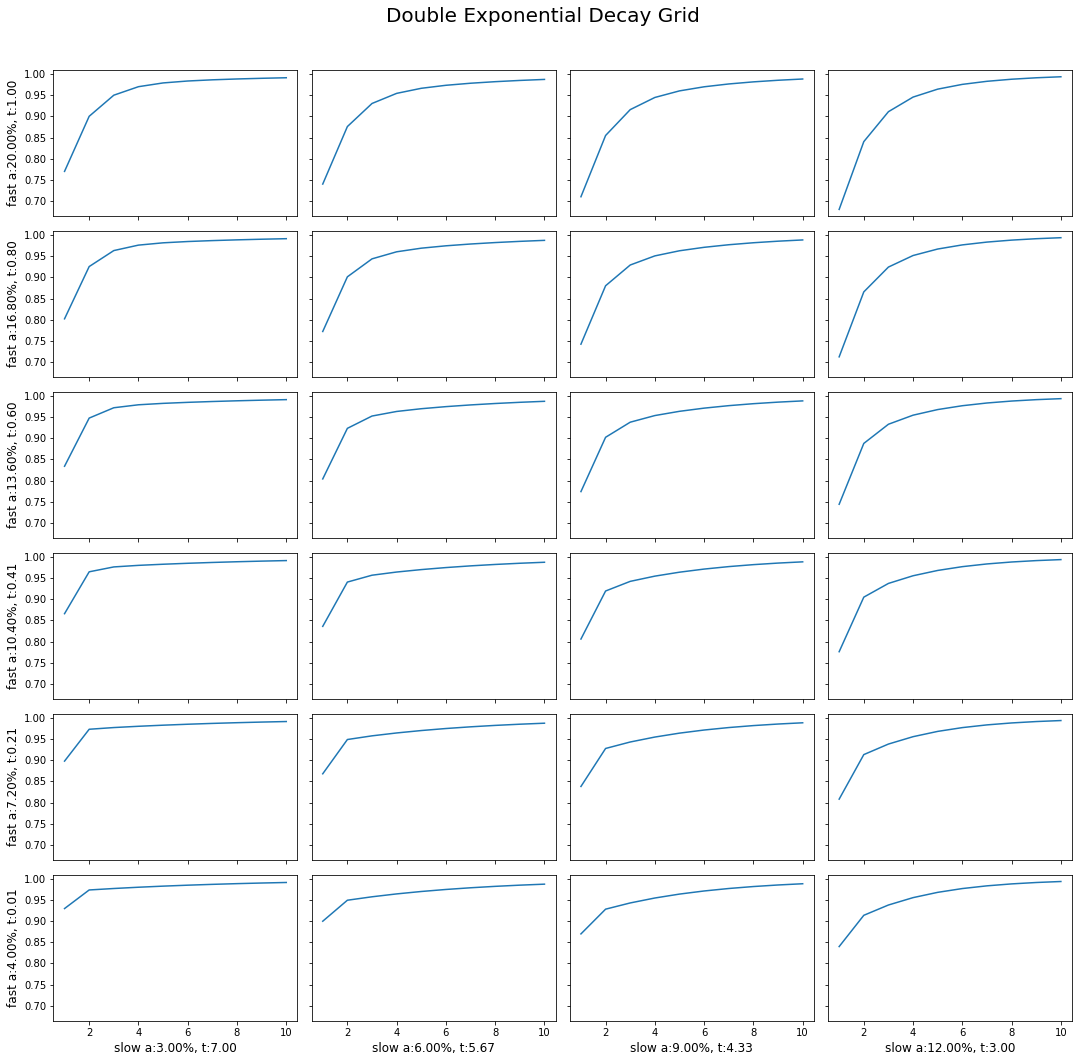

In [31]:
## ILLUSTRATION OF THE GRID!!

def double_exp_decay_func(afast, tfast, aslow, tslow, xlims, stepsize):
    """input parameters of double exponential decay and returns and x and y array
    input:  afast: magnitude of fast adaptation
            tfast: recovery of fast adaptation
            aslow: magnitde of slow adaptation
            tslow: recovery of slow adaptation
    output: return np.array for x and y
    """
    # define x and y arrays
    return_x = np.arange(xlims[0], xlims[1]+stepsize, stepsize)
    return_y = np.zeros(return_x.shape[0])
    # get y value for each step x
    for x in range(return_x.shape[0]):
        return_y[x] = 1 - (afast * np.exp(-(return_x[x]-1)/tfast)) - (aslow * np.exp(-(return_x[x]-1)/tslow))
    return(return_x, return_y) # return x and y array


# grid positions (fast a and t are linked)
afast = np.linspace(20, 4, 6)
tfast = np.linspace(1, 0.01, 6)

# grid postions (slow a and t are linked)
aslow = np.linspace(3, 12, 4)
tslow = np.linspace(7, 3, 4)

# create the full grid
grid = np.array([[i, j] for i in range(len(afast)) for j in range(len(aslow))])

# predefine empty dict
decay_data = {}

# predefine figure
fig, axs = plt.subplots(np.max(grid[:,0])+1, np.max(grid[:,1])+1, figsize=(15,15), sharex=True, sharey=True)
fig.suptitle('Double Exponential Decay Grid', fontsize=20)

for gridpos in range(grid.shape[0]):
    
    # get current gridposition values
    afa = afast[grid[gridpos,0]] / 100
    tfa = tfast[grid[gridpos,0]]
    asl = aslow[grid[gridpos,1]] / 100
    tsl = tslow[grid[gridpos,1]]

    # do the longtrace model for current gridpos
    x_decay, y_decay = double_exp_decay_func(afa, tfa, asl, tsl, [1, 10], 1)
    
    # save to dict
    key = f'af:{afa:.2f},tf:{tfa:.2f},as:{asl:.2f},ts:{tsl:.2f}'
    decay_data[key] = {'x_decay': x_decay, 'y_decay': y_decay}
    
    ax = axs[grid[gridpos,0], grid[gridpos,1]]
    ax.plot(x_decay, y_decay)
    
    # Set the subtitles for rows and columns
    if grid[gridpos,1] == 0:
        ax.set_ylabel(f'fast a:{afa*100:.2f}%, t:{tfa:.2f}', fontsize=12)
    if grid[gridpos,0] == len(afast) - 1:
        ax.set_xlabel(f'slow a:{asl*100:.2f}%, t:{tsl:.2f}', fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()